In [1]:
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from functools import partial


import sys
from pathlib import Path
repo_root = Path.cwd()
sys.path.append(str(repo_root.parent))

from config.plot_config import plot_config
output = plot_config() / "task2"
output.mkdir(exist_ok=True)

/Users/petterollinen/venvs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from helpers import DataAnalysis
analysis = DataAnalysis.from_csv("spiff_data-2.csv").clean()
prices = analysis.prices
gap_table = analysis.gap_table()
internal_gaps = gap_table[gap_table["gap_type"] == "internal"].copy()
log_return_data=analysis.log_returns

In [3]:
internal_gaps

,series,start,end,length,gap_type
0,gurkor,199,248,50,internal
2,guitars,399,448,50,internal
4,slingshots,599,648,50,internal
6,stocks,799,848,50,internal
8,sugar,999,1048,50,internal
10,water,1199,1248,50,internal
12,tranquillity,1399,1448,50,internal


In [4]:
def garch_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Fill a contiguous gap using a two-sided Student-t GARCH(1,1) bridge.

    GARCH(1,1) with Student-t innovations is fit on pre-gap returns (forward)
    and negated/time-reversed post-gap returns (backward).  The two resulting
    horizon-length variance schedules are blended linearly across the gap.
    Paths are drawn with Student-t innovations scaled by those heteroskedastic
    step variances, then individually corrected so every path exactly hits both
    the left and right log-price endpoints (Doob h-transform style).
    """
    import warnings as _warnings

    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()

    # ── 1. Endpoints in log space ─────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("Two-sided GARCH bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Log-return calibration windows ────────────────────────────────
    def log_ret(s: pd.Series) -> pd.Series:
        return np.log(s / s.shift(1)).dropna()

    pre_returns  = log_ret(pre.iloc[-calibration_window:])
    post_returns = log_ret(post.iloc[:calibration_window])

    if len(pre_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} pre-gap returns, got {len(pre_returns)}.")
    if len(post_returns) < MIN_OBS:
        raise ValueError(f"Need ≥{MIN_OBS} post-gap returns, got {len(post_returns)}.")

    # ── 3. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length — check start_day / end_day.")

    horizon = gap_len + 1   # bridge needs one extra step

    # ── 4. Fit GARCH(1,1)-t → horizon conditional variance forecast ───────
    def fit_garch_variances(returns: pd.Series, h: int, reverse: bool = False):
        clean = returns.dropna().astype(float)
        if reverse:
            clean = -clean.iloc[::-1]      # negate + time-reverse for backward pass
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            model  = arch_model(clean * 100, mean="Zero", vol="GARCH", p=1, q=1,
                                dist="StudentsT", rescale=False)
            result = model.fit(disp="off", show_warning=False)
            fc     = result.forecast(horizon=h, reindex=False)
        variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4
        if not np.isfinite(variances).all() or np.any(variances <= 0):
            raise ValueError("GARCH produced non-finite variance forecast.")
        nu = float(result.params.get("nu", np.nan))
        return variances, nu

    pre_vars,      nu_pre  = fit_garch_variances(pre_returns,  horizon, reverse=False)
    post_vars_bwd, nu_post = fit_garch_variances(post_returns, horizon, reverse=True)
    post_vars = post_vars_bwd[::-1]    # flip to align with gap direction

    # ── 5. Blend variance schedules ───────────────────────────────────────
    lw            = np.linspace(1.0, 0.0, horizon)
    step_variances = np.maximum(lw * pre_vars + (1 - lw) * post_vars, 1e-12)

    # Use the fatter-tailed (smaller) valid ν — conservative choice
    nu_valid = [nu for nu in (nu_pre, nu_post) if np.isfinite(nu) and nu > 2.05]
    if not nu_valid:
        raise ValueError(f"Invalid degrees of freedom from GARCH fits: {nu_pre=}, {nu_post=}.")
    bridge_nu = float(min(nu_valid))

    # ── 6. Conditional Student-t bridge paths ─────────────────────────────
    # Standardised t innovations (unit variance) scaled by sqrt(step_var),
    # then every path's increments are shifted to sum to right_log - left_log,
    # weighted by variance share — pins both endpoints on every path.
    total_move     = right_log - left_log
    total_variance = float(step_variances.sum())

    dof = bridge_nu if (np.isfinite(bridge_nu) and bridge_nu > 2.05) else 8.0
    z   = rng.standard_t(dof, size=(n_simulations, horizon)) * np.sqrt((dof - 2.0) / dof)

    raw_inc = z * np.sqrt(step_variances)[None, :]
    raw_sum = raw_inc.sum(axis=1)
    weights = step_variances / total_variance
    adj_inc = raw_inc + (total_move - raw_sum)[:, None] * weights[None, :]

    log_paths = left_log + np.cumsum(adj_inc, axis=1)[:, :-1]   # (n_sims, gap_len)
    paths     = np.exp(log_paths)

    # ── 7. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "garch_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "nu_pre":      nu_pre,
        "nu_post":     nu_post,
        "bridge_nu":   bridge_nu,
    }


In [5]:
def cross_garch_bridge(
    price_series: pd.Series,
    start_day,
    end_day,
    prices_df: pd.DataFrame,
    n_simulations: int = 1000,
    calibration_window: int = 60,
    random_seed: int | None = None,
) -> dict:
    """
    Factor model with GARCH(1,1)-t errors: cross-series OLS signal + GARCH residual bridge.

    Step 1 – OLS: r_target = r_hat (companions) + epsilon, fit on pre-gap window.
    Step 2 – GARCH: fit GARCH(1,1)-t on the pre-gap OLS *residuals* (forward) and
              negated/reversed post-gap residuals (backward, using the same betas).
              Blend the two variance schedules linearly across the gap.
    Step 3 – Bridge: draw Student-t innovations scaled by the blended schedule,
              correct every path so its residuals sum to
              (right_log - left_log) - sum(r_hat), then add the companion signal.

    The OLS signal carries directional cross-series information; the GARCH schedule
    captures volatility clustering in the idiosyncratic residuals that plain OLS misses.
    """
    import warnings as _warnings

    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().copy()
    target = series.name

    # ── 1. Endpoints ──────────────────────────────────────────────────────
    pre  = series[series.index < start_day].dropna()
    post = series[series.index > end_day].dropna()

    if len(pre) == 0:
        raise ValueError("No observations before start_day.")
    if len(post) == 0:
        raise ValueError("cross_garch_bridge requires observations after end_day.")

    left_log  = float(np.log(pre.iloc[-1]))
    right_log = float(np.log(post.iloc[0]))

    # ── 2. Gap index ──────────────────────────────────────────────────────
    try:
        freq      = pd.infer_freq(series.index)
        gap_index = pd.date_range(start=start_day, end=end_day, freq=freq or "D")
    except (TypeError, ValueError):
        gap_index = pd.RangeIndex(start=int(start_day), stop=int(end_day) + 1)

    gap_len = len(gap_index)
    if gap_len == 0:
        raise ValueError("Gap has zero length.")

    horizon = gap_len + 1

    # ── 3. Log-returns + companion selection ─────────────────────────────
    all_lr     = np.log(prices_df / prices_df.shift(1))
    candidates = [c for c in prices_df.columns if c != target]
    gap_lr     = all_lr.loc[(all_lr.index >= start_day) & (all_lr.index <= end_day), candidates]
    companions = gap_lr.dropna(axis=1).columns.tolist()

    if not companions:
        raise ValueError("No companion series with complete data during the gap.")

    # ── 4. OLS on pre-gap window → betas + residuals ──────────────────────
    cal_lr = (
        all_lr.loc[all_lr.index < start_day, [target] + companions]
        .dropna()
        .iloc[-calibration_window:]
    )
    if len(cal_lr) < max(MIN_OBS, len(companions) + 2):
        raise ValueError(f"Too few calibration observations ({len(cal_lr)}).")

    y_cal  = cal_lr[target].values
    X_cal  = np.column_stack([np.ones(len(y_cal)), cal_lr[companions].values])
    betas, _, _, _ = np.linalg.lstsq(X_cal, y_cal, rcond=None)
    r_sq   = float(1 - np.var(y_cal - X_cal @ betas) / np.var(y_cal))

    pre_resid = pd.Series(y_cal - X_cal @ betas, index=cal_lr.index)

    # Post-gap residuals use the same betas (no re-fit on small post-gap sample)
    post_lr = (
        all_lr.loc[all_lr.index > end_day, [target] + companions]
        .dropna()
        .iloc[:calibration_window]
    )
    if len(post_lr) >= MIN_OBS:
        y_post     = post_lr[target].values
        X_post     = np.column_stack([np.ones(len(y_post)), post_lr[companions].values])
        post_resid = pd.Series(y_post - X_post @ betas, index=post_lr.index)
    else:
        post_resid = pre_resid

    # ── 5. GARCH(1,1)-t on OLS residuals → variance schedule ─────────────
    def fit_garch_variances(resid: pd.Series, h: int, reverse: bool = False):
        clean = resid.dropna().astype(float)
        if reverse:
            clean = -clean.iloc[::-1]
        with _warnings.catch_warnings():
            _warnings.simplefilter("ignore")
            model  = arch_model(clean * 100, mean="Zero", vol="GARCH", p=1, q=1,
                                dist="StudentsT", rescale=False)
            result = model.fit(disp="off", show_warning=False)
            fc     = result.forecast(horizon=h, reindex=False)
        variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4
        if not np.isfinite(variances).all() or np.any(variances <= 0):
            raise ValueError("GARCH produced non-finite variance forecast.")
        nu = float(result.params.get("nu", np.nan))
        return variances, nu

    pre_vars,      nu_pre  = fit_garch_variances(pre_resid,  horizon, reverse=False)
    post_vars_bwd, nu_post = fit_garch_variances(post_resid, horizon, reverse=True)
    post_vars = post_vars_bwd[::-1]

    lw             = np.linspace(1.0, 0.0, horizon)
    step_variances = np.maximum(lw * pre_vars + (1 - lw) * post_vars, 1e-12)

    nu_valid  = [nu for nu in (nu_pre, nu_post) if np.isfinite(nu) and nu > 2.05]
    if not nu_valid:
        raise ValueError(f"Invalid GARCH degrees of freedom: {nu_pre=}, {nu_post=}.")
    bridge_nu = float(min(nu_valid))

    # ── 6. Companion signal during the gap ────────────────────────────────
    X_gap = np.column_stack([np.ones(gap_len), gap_lr[companions].values])
    r_hat = X_gap @ betas   # (gap_len,) deterministic log-return prediction

    # ── 7. Conditional Student-t bridge on residuals ──────────────────────
    # Residuals must sum to: (right_log - left_log) - sum(r_hat)
    resid_target   = (right_log - left_log) - float(r_hat.sum())
    total_variance = float(step_variances.sum())

    dof = bridge_nu if (np.isfinite(bridge_nu) and bridge_nu > 2.05) else 8.0
    z   = rng.standard_t(dof, size=(n_simulations, horizon)) * np.sqrt((dof - 2.0) / dof)

    raw_inc = z * np.sqrt(step_variances)[None, :]
    raw_sum = raw_inc.sum(axis=1)
    weights = step_variances / total_variance
    adj_inc = raw_inc + (resid_target - raw_sum)[:, None] * weights[None, :]

    # Combine signal + bridge-corrected residuals over the gap_len steps
    combined = r_hat[None, :] + adj_inc[:, :-1]   # (n_sims, gap_len)
    log_paths = left_log + np.cumsum(combined, axis=1)
    paths     = np.exp(log_paths)

    # ── 8. Uncertainty measures ───────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    outside     = series[(series.index < start_day) | (series.index > end_day)]
    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([outside, gap_fill]).sort_index()

    return {
        "method":      "cross_garch_bridge",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "companions":  companions,
        "r_squared":   r_sq,
        "nu_pre":      nu_pre,
        "nu_post":     nu_post,
        "bridge_nu":   bridge_nu,
        "betas":       dict(zip(["intercept"] + companions, betas)),
    }


In [6]:
def backtest_interpolation(
    method,
    price_series: pd.Series,
    n_backtests: int = 50,
    gap_length: int = 50,
    start_from: int = 1500,
    **method_kwargs,
) -> pd.DataFrame:
    """
    Backtest a gap-interpolation method on pseudo gaps cut from observed data.

    For each backtest, a contiguous block of `gap_length` days is masked out
    of the series starting at or after `start_from`.  The method is called on
    the *unmasked* series (it sees the true pre- and post-gap flanks) and its
    output is compared to the true prices in the hidden block.

    Parameters
    ----------
    method : callable
        One of random_walk, garch_bridge, or any function with the same
        signature: (price_series, start_day, end_day, **kwargs) -> dict.
    price_series : pd.Series
        Full observed (clean) price series.
    n_backtests : int
        How many pseudo gaps to test.
    gap_length : int
        Number of days in each pseudo gap (default 50, matching real gaps).
    start_from : int
        Earliest index value from which pseudo gaps may start.
    **method_kwargs
        Forwarded verbatim to `method` (e.g. calibration_window, n_simulations).
        Omit random_seed to let each call vary independently.

    Returns
    -------
    pd.DataFrame
        One row per completed backtest with columns:
        start_day, end_day, rmse, mae, mape_pct, rmse_log,
        coverage_90, coverage_50, mean_width_90_pct
    """
    rng   = np.random.default_rng(method_kwargs.pop("random_seed", None))
    index = price_series.index
    n     = len(index)

    cal_win    = method_kwargs.get("calibration_window", 60)
    min_pre    = cal_win + 1          # returns needed before gap
    min_post   = cal_win + 1         # returns needed after gap

    # Collect every valid positional start index
    start_pos = next((i for i, v in enumerate(index) if v >= start_from), None)
    if start_pos is None:
        raise ValueError(f"No index values ≥ {start_from} found in series.")

    valid = [
        i for i in range(start_pos, n - gap_length - min_post)
        if i >= min_pre
        and price_series.iloc[i - 1 : i + gap_length + 1].notna().all()
    ]

    if not valid:
        raise ValueError(
            f"No valid pseudo-gap positions found from index {start_from} "
            f"(need {min_pre} pre-obs and {min_post} post-obs)."
        )

    chosen = (
        valid if n_backtests >= len(valid)
        else sorted(rng.choice(valid, size=n_backtests, replace=False).tolist())
    )

    records = []
    for pos in chosen:
        start_day  = index[pos]
        end_day    = index[pos + gap_length - 1]
        true_prices = price_series.iloc[pos : pos + gap_length].to_numpy(dtype=float)

        try:
            result = method(price_series, start_day, end_day, **method_kwargs)
        except Exception as exc:
            records.append({"start_day": start_day, "end_day": end_day, "error": str(exc)})
            continue

        median = result["median"]
        pct    = result.get("percentiles")

        log_true = np.log(true_prices)
        log_pred = np.log(median)

        rec = {
            "start_day":  start_day,
            "end_day":    end_day,
            "rmse":       float(np.sqrt(np.mean((median - true_prices) ** 2))),
            "mae":        float(np.mean(np.abs(median - true_prices))),
            "mape_pct":   float(np.mean(np.abs((median - true_prices) / true_prices)) * 100),
        }

        if pct is not None:
            p5,  p95 = pct["p5"].values,  pct["p95"].values
            p25, p75 = pct["p25"].values, pct["p75"].values
            rec["coverage_90"]      = float(np.mean((true_prices >= p5)  & (true_prices <= p95)))
            rec["coverage_50"]      = float(np.mean((true_prices >= p25) & (true_prices <= p75)))
            rec["mean_width_90_pct"] = float(np.mean((p95 - p5) / true_prices) * 100)

        records.append(rec)

    return pd.DataFrame(records)


In [7]:


mean_cols = ["rmse", "mape_pct", "coverage_90", "coverage_50", "mean_width_90_pct"]
summary_cols = ["rmse", "mape_pct", "mape_pct_max", "coverage_90", "coverage_50", "mean_width_90_pct"]
methods = {
    "single":      garch_bridge,
    "cross":       partial(cross_garch_bridge,  prices_df=prices),
}

backtest_jobs = [
    (series_name, method_name, method_fn)
    for series_name in internal_gaps["series"].tolist()
    for method_name, method_fn in methods.items()
]

rows = []
for series_name, method_name, method_fn in tqdm(backtest_jobs, desc="Backtesting models"):
    ps = prices[series_name]
    try:
        bt = backtest_interpolation(method_fn, ps, n_backtests=500, random_seed=42)
        means = bt[mean_cols].mean().to_dict()
        means["mape_pct_max"] = float(bt["mape_pct"].max())
    except Exception as exc:
        means = {c: np.nan for c in summary_cols}
        means["error"] = str(exc)
    means["series"] = series_name
    means["method"] = method_name
    rows.append(means)

all_results = (
    pd.DataFrame(rows)
    .set_index(["series", "method"])[summary_cols]
    .round(4)
)
display(all_results.round(2))
all_results.to_latex(output / "task2-reuslts-table.tex", float_format="{:0.2f}".format)


Backtesting models: 100%|██████████| 14/14 [04:47<00:00, 20.55s/it]


rmse  mape_pct  mape_pct_max  coverage_90  coverage_50  \
series       method                                                           
gurkor       single  0.10      0.82          3.27         0.89         0.51   
             cross   0.07      0.58          2.67         0.91         0.55   
guitars      single  0.23      3.12         16.14         0.89         0.52   
             cross   0.17      2.24         10.50         0.90         0.53   
slingshots   single  0.13      3.02         12.00         0.91         0.54   
             cross   0.11      2.34         10.64         0.92         0.55   
stocks       single  0.21      3.20          9.17         0.91         0.53   
             cross   0.23      3.45         10.35         0.89         0.50   
sugar        single  0.09      3.06         12.72         0.89         0.49   
             cross   0.08      2.79         11.43         0.91         0.53   
water        single  0.06      0.75          2.31         0.89         0.50   
             cross   0.04      0.53          1.89         0.89         0.52   
tranquillity single  0.40      2.66          9.34         0.91         0.51   
             cross   0.41      2.72          9.88         0.89         0.49   

                     mean_width_90_pct  
series       method                     
gurkor       single               3.61  
             cross                2.64  
guitars      single              13.70  
             cross               10.29  
slingshots   single              13.91  
             cross               11.19  
stocks       single              14.09  
             cross               14.22  
sugar        single              13.34  
             cross               12.90  
water        single               3.19  
             cross                2.34  
tranquillity single              12.00  
             cross               11.39

In [8]:
# ── Cross-series lift over best single-series baseline ───────────────────────
single_methods = ["single"]
cross_methods  = ["cross"]

m = all_results.index.get_level_values("method")
best_single = all_results[m.isin(single_methods)].groupby("series")["mape_pct"].min()
best_cross  = all_results[m.isin(cross_methods) ].groupby("series")["mape_pct"].min()

lift = pd.DataFrame({
    "best_single_mape": best_single,
    "best_cross_mape":  best_cross,
})
lift["mape_reduction_%"] = (
    (lift["best_single_mape"] - lift["best_cross_mape"]) / lift["best_single_mape"] * 100
).round(1)

display(lift.round(3))
lift=lift.round(2)
lift.to_latex(output / "task2-reuslts-table.tex", float_format="{:0.2f}".format)

,best_single_mape,best_cross_mape,mape_reduction_%
series,,,
guitars,3.115,2.242,28.0
gurkor,0.824,0.578,29.9
slingshots,3.025,2.338,22.7
stocks,3.198,3.452,-7.9
sugar,3.058,2.786,8.9
tranquillity,2.663,2.724,-2.3
water,0.749,0.529,29.4


In [9]:
def plot_gap_interpolation(
    price_series: pd.Series,
    gap_start,
    gap_end,
    result: dict,
    zoom_pad: int = 60,
    title: str | None = None,
):
    x_lo = gap_start - zoom_pad
    x_hi = gap_end + zoom_pad

    pct = result.get("percentiles")
    median = result["median"]
    gap_index = result["gap_index"]

    visible_obs = price_series[(price_series.index >= x_lo) & (price_series.index <= x_hi)].dropna()
    y_candidates = [visible_obs.values, median]
    if pct is not None:
        y_candidates += [pct["p5"].values, pct["p95"].values]
    y_all = np.concatenate(y_candidates)
    y_pad = (y_all.max() - y_all.min()) * 0.05
    y_lo, y_hi = y_all.min() - y_pad, y_all.max() + y_pad

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(price_series.index, price_series.values, color="steelblue", label="Observed", zorder=3)

    if pct is not None:
        ax.fill_between(pct.index, pct["p5"], pct["p95"], alpha=0.15, color="orange", label="5–95 pct")
        ax.fill_between(pct.index, pct["p25"], pct["p75"], alpha=0.30, color="orange", label="25–75 pct")

    method_label = result.get("method", "interpolated")
    ax.plot(gap_index, median, color="orange", linewidth=2, label=f"{method_label} median")

    ax.axvspan(gap_start, gap_end, alpha=0.08, color="red", label="Gap region")
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)

    name = getattr(price_series, "name", "")
    ax.set_title(title or f"{name} – {method_label} gap interpolation (zoomed)")
    ax.set_xlabel("Index")
    ax.set_ylabel("Price")
    ax.legend()
    plt.tight_layout()
    plt.show()


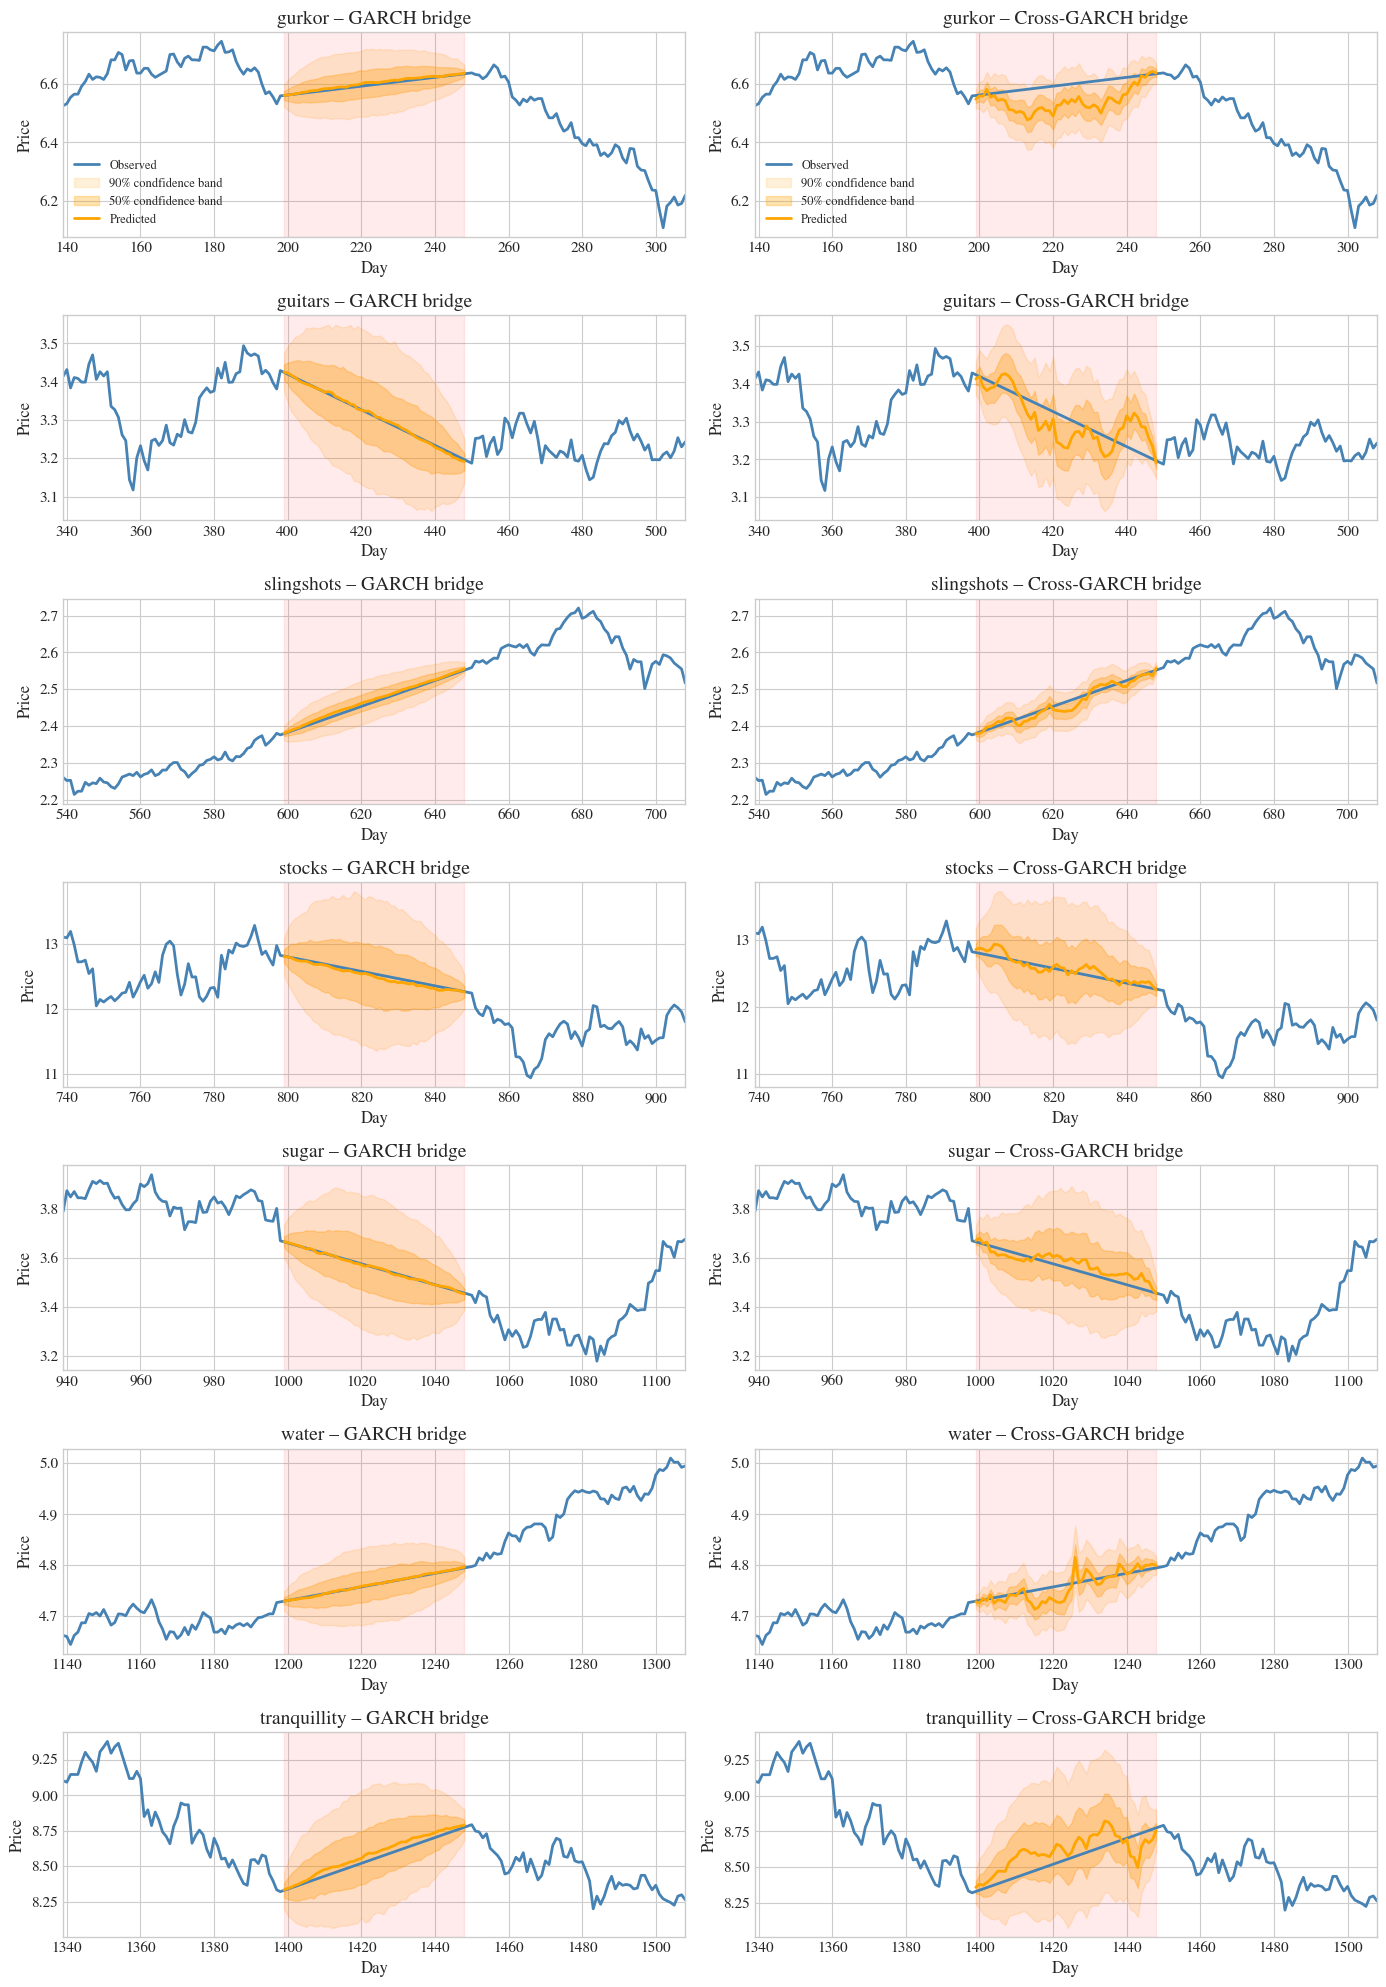

In [10]:


series_list = internal_gaps["series"].tolist()
fig, axes = plt.subplots(7, 2, figsize=(14, 20))

for row_idx, series_name in enumerate(series_list):
    gap_row  = internal_gaps[internal_gaps["series"] == series_name].iloc[0]
    gap_start, gap_end = int(gap_row["start"]), int(gap_row["end"])
    ps = prices[series_name]

    masked = ps.copy()
    masked.iloc[gap_start : gap_end + 1] = np.nan

    res_single = garch_bridge(masked.dropna(), gap_start, gap_end, n_simulations=1000, random_seed=42)
    res_cross  = cross_garch_bridge(masked.dropna(), gap_start, gap_end, prices_df=prices, n_simulations=1000, random_seed=42)

    true_gap = ps.iloc[gap_start : gap_end + 1]
    x_lo, x_hi = gap_start - 60, gap_end + 60
    visible = masked[(masked.index >= x_lo) & (masked.index <= x_hi)].dropna()

    for col_idx, (res, label) in enumerate([(res_single, "GARCH bridge"), (res_cross, "Cross-GARCH bridge")]):
        ax  = axes[row_idx, col_idx]
        pct = res["percentiles"]

        ax.plot(visible.index, visible.values, color="steelblue", label="Observed")
        #ax.plot(true_gap.index, true_gap.values, color="green", linewidth=1.5, linestyle="--", label="Actual")
        ax.fill_between(pct.index, pct["p5"], pct["p95"], alpha=0.15, color="orange",label='90% condfidence band')
        ax.fill_between(pct.index, pct["p25"], pct["p75"], alpha=0.30, color="orange",label='50% condfidence band')
        ax.plot(res["gap_index"], res["median"], color="orange", label="Predicted")
        ax.axvspan(gap_start, gap_end, alpha=0.08, color="red")
        ax.set_xlim(x_lo, x_hi)
        ax.set_title(f"{series_name} – {label}")
        ax.set_xlabel("Day")
        ax.set_ylabel("Price")
        if row_idx == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(output / "task2_gap_predictions.pdf", bbox_inches="tight")
plt.show()
